In [42]:
from ROOT import TF1, TH1F, TCanvas, TColor, kRed, kBlack
import numpy as np
import csv
import pandas as pd
import matplotlib.pyplot as plt

In [163]:
def fit_amplitudes(data,ampl_ranges,draw=False,test=False):
    can = 1


    y = data['pulse_height_V'].to_numpy()
        

    test = TH1F("ampl","ampl",150,0,np.max(y)+.5)
    
    for thing in y:
        test.Fill(thing)
        
    fits = []
    ampl = []
    err = []
    
    if(draw): 
        can = TCanvas()
        test.Draw("HIST")
    
    for i,xs in enumerate(ampl_ranges):
        epsilon = 0
        if(i > 0) : epsilon = .4
        lin_fit = TF1(f"pol1_{i}", "pol1", xs[0]-epsilon, xs[1]+epsilon)
        fit = TF1(f"gaus_{i}", "gaus", xs[0], xs[1])
        fit.SetLineColor(kRed)
        lin_fit.SetLineColor(kBlack)
        test.Fit(fit,"RQ0")
        test.Fit(lin_fit,"RQ0")
        
        if(draw): 
            fit.Draw("L SAME")
            lin_fit.Draw("L SAME")
        fits.append([fit,lin_fit])
    
        bin_min = test.GetXaxis().FindBin(xs[0]);
        bin_max = test.GetXaxis().FindBin(xs[1]);
        n = test.Integral(bin_min,bin_max)
        # se = fit.GetParError(2)
        se = fit.GetParameter(2)#/np.sqrt(n)
        
        ampl.append(fit.GetParameter(1))
        err.append(se)
    if(draw): can.Draw()
    return ampl,err,[can, fits, test]

<Axes: ylabel='Frequency'>

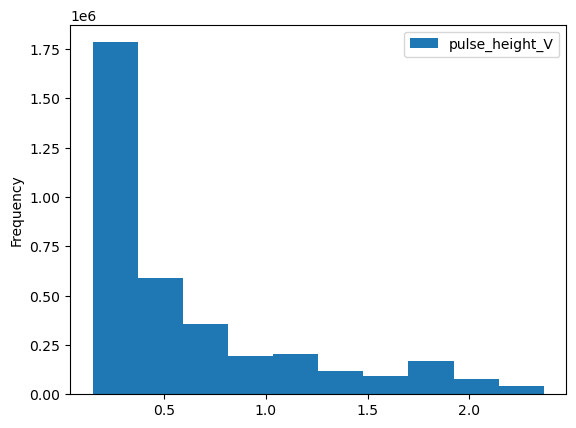

In [164]:
k40_path  = '~/Downloads/111_KCl_overnight.csv'
co60_path = '~/Downloads/co60_30min.csv'
th232_path= '~/Downloads/111_source_overnight_100MHz.csv'

k40_data  = pd.read_csv(k40_path)
co60_data = pd.read_csv(co60_path)
th232_data= pd.read_csv(th232_path)

combined_data = pd.concat([k40_data,co60_data,th232_data])
combined_data.plot(kind="hist")

In [170]:
co60_bins = [[.15, .23], [1.2,1.4], [1.4,1.7]]
k40_bins  = [[.18,.22], [1.7,2],[1.95, 2.05]]
th232_bins= [[.18,.22],[.26,.38],[.4,.5],[.7,.8],[1.1,1.3],[1.5,1.7],[1.95,2.1]]
combined_bins = [[.18,.22], [1.6,2.1]]

co60_means, co60_errs, rots1         = fit_amplitudes(co60_data,co60_bins,draw=False)
k40_means, k40_errs, rots2           = fit_amplitudes(k40_data,k40_bins,draw=False)
th232_means, th232_errs, rots3           = fit_amplitudes(th232_data,th232_bins,draw=True)
combined_means, combined_errs, rots4 = fit_amplitudes(combined_data,combined_bins,draw=False)

Warning in <TROOT::Append>: Replacing existing TH1: ampl (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: ampl (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: ampl (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: ampl (Potential memory leak).


co60
[0.511, 1.17, 1.33]
3 3 3
k40
[0.511, 1.46]
2 2 2
combined
[0.511, 1.46]
2 2 2
wth is this E = 1.532423181916215
Calibrated th232 spectrum peaks:
0.199 V --> 0.512 MeV
0.313 V --> 0.580 MeV
0.429 V --> 0.649 MeV
0.750 V --> 0.841 MeV
1.174 V --> 1.093 MeV
1.571 V --> 1.330 MeV
2.016 V --> 1.595 MeV


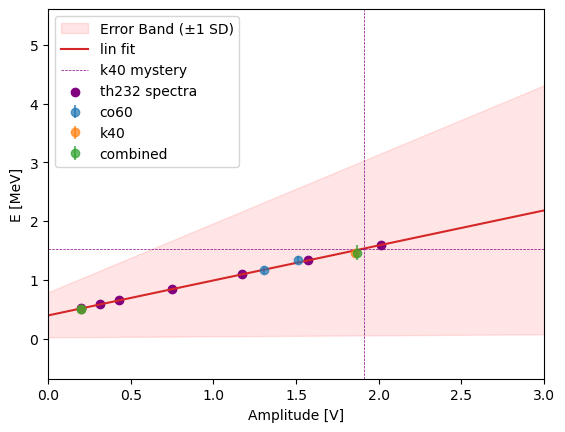

In [180]:
iso_to_peaks = {'co60':[[.511, 1.17,1.33],co60_means,co60_errs],
                'k40':[[.511, 1.460],k40_means, k40_errs],
                'combined':[[.511, 1.46,],combined_means, combined_errs]
               }

combo_peaks = [.511,1.17,1.33,1.46]
combo_means = [np.average([co60_means[0],k40_means[0],combined_means[0]]),co60_means[1],co60_means[2],np.average([k40_means[1],combined_means[1]])]
combo_errs  = np.array([np.average([co60_errs[0],k40_errs[0],combined_errs[0]]),co60_errs[1],co60_errs[2],np.average([k40_errs[1],combined_errs[1]])])
par, cov= np.polyfit(combo_means, combo_peaks, deg=1, w=1/combo_errs,cov=True)
m,c = par
errors = np.sqrt(np.diag(cov))


for i,iso in enumerate(iso_to_peaks):
    print(iso)
    data = iso_to_peaks[iso]
    # print(data[1])
    n_peaks = len(data[0])
    
    peaks = data[0]
    print(peaks)
    volts = data[1][:n_peaks]
    v_err = np.array(data[2][:n_peaks])

    print(len(peaks),len(volts),len(v_err))
    plt.errorbar(volts,peaks,yerr=v_err,fmt='o',label=iso,alpha=.7)

x = np.linspace(0-1,np.max(combined_means)+2,10)
y = x*m+c

y_lower = y-x*(m-errors[0])-(c-errors[1])
y_upper = y+x*(m-errors[0])+(c-errors[1])
plt.fill_between(x, y_lower, y_upper, color='red', alpha=0.1, label='Error Band (±1 SD)')

plt.plot(x,y,label='lin fit')
plt.ylabel("E [MeV]")
plt.xlabel("Amplitude [V]")
plt.xlim(0,3)



plt.axvline(k40_means[2],color='purple', linestyle="--", linewidth=.5)
plt.axhline(k40_means[2]*m+c,color='purple', linestyle="--",linewidth=.5, label="k40 mystery")
print(f"wth is this E = {k40_means[2]*m+c}")
print("Calibrated th232 spectrum peaks:")
energies = np.array(th232_means)*m+c
plt.scatter(th232_means,energies,marker='o',color='purple',label="th232 spectra")
for peak,E in zip(th232_means,energies):
#     E = peak*m+c
#     plt.axvline(peak,color='grey', linestyle="--", linewidth=.5)
#     if(i == 0): plt.axhline(E,color='grey', linestyle="--",linewidth=.5, label="th232 spectra")
#     else:       plt.axhline(E,color='grey', linestyle="--",linewidth=.5)
    print(f"{peak:.3f} V --> {E:.3f} MeV")

    

plt.legend()
plt.show()
                

In [153]:
h = TH1F('','',200,0,3)
for ampl in th232_data['pulse_height_V'].to_numpy():
    h.Fill(ampl)

In [154]:
c = TCanvas()
h.Draw("HIST")
c.Draw()

In [150]:
max(combined_data['pulse_height_V'])

2.364848